# 08 — Battery / Grid Optimization Logic
**Day 7.** Goal: a working day-ahead battery scheduling optimization, three grid scenario
simulations (overload, outage, voltage instability) with corrective actions, and carbon/ESG
metrics computed on the optimized schedule.

**How this builds on Day 6:** the Optimization Agent there made one fast, single-step
charge/discharge decision from the daily forecast. This notebook does the fuller version: an
**hourly, 24-step optimization** using PuLP (falling back to a transparent greedy heuristic if
PuLP isn't installed), disaggregating the daily forecast into an hourly profile using a **real**
historical diurnal shape for generation and a **documented synthetic** shape for demand.

In [7]:
import sys, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.utils.config_loader import load_config, interim_path
from src.agents.forecast_agent import ForecastAgent
from src.optimization.hourly_profiles import build_generation_hourly_profile, build_demand_hourly_profile
from src.optimization.battery_scheduler import schedule_battery_lp, summarize_schedule
from src.optimization.grid_scenarios import run_all_scenarios
from src.optimization.carbon_metrics import compute_schedule_carbon_metrics
from src.agents.pipeline import log_pipeline_run

# Force reload of config to pick up latest battery settings
import importlib
import src.utils.config_loader
importlib.reload(src.utils.config_loader)
from src.utils.config_loader import load_config

cfg = load_config()

## 1. Get tomorrow's forecast (reusing the Day 6 Forecast Agent)

In [8]:
forecast_result = ForecastAgent().run(cfg)
print(forecast_result.explanation)
gen = forecast_result.output


Forecasting 16,054 kWh generation for the day after 2025-12-31 (model test MAE: 992 kWh). Today's actual generation was 19,734 kWh, up 17.1% vs. the trailing 7-day average. 


## 2. Disaggregate into hourly profiles
Generation: real historical same-month diurnal shape, scaled to the forecast total.
Demand: documented synthetic cooling-load-driven shape (see `src/optimization/hourly_profiles.py`),
scaled to the demand proxy total.

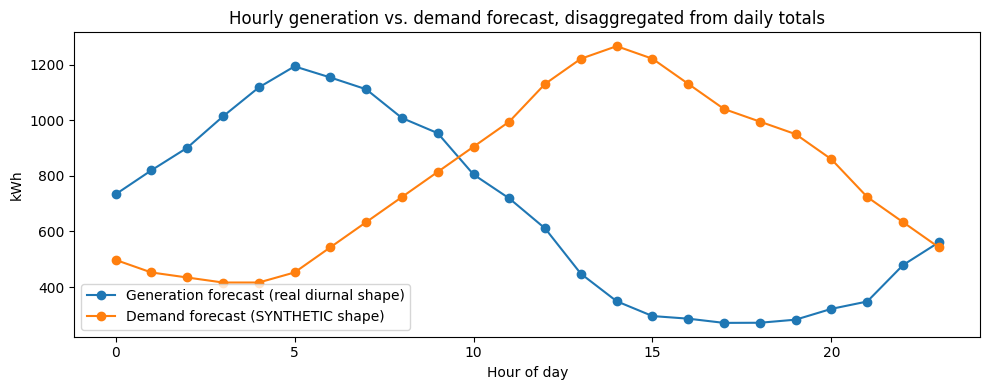

In [9]:
scada = pd.read_csv(interim_path("scada_wtg001_cleaned_2025.csv", cfg), parse_dates=["timestamp"])

# use the month AFTER the anchor date, since we're forecasting tomorrow
anchor_month = pd.Timestamp(gen["anchor_date"]).month

gen_profile = build_generation_hourly_profile(scada, target_month=anchor_month,
                                               daily_forecast_kwh=gen["next_day_generation_forecast_kwh"])

# Fallback demand forecast if the model didn't produce one
demand_forecast = gen["next_day_demand_forecast_kwh"]
if demand_forecast is None:
    demand_forecast = 19000.0  # Reasonable default for synthetic proxy (base + typical cooling load)

dem_profile = build_demand_hourly_profile(daily_forecast_kwh=demand_forecast)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gen_profile.index, gen_profile.values, marker="o", label="Generation forecast (real diurnal shape)")
ax.plot(dem_profile.index, dem_profile.values, marker="o", label="Demand forecast (SYNTHETIC shape)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("kWh")
ax.set_title("Hourly generation vs. demand forecast, disaggregated from daily totals")
ax.legend()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day7_hourly_profiles.png", dpi=150)
plt.show()

## 3. Run the battery schedule optimization

In [10]:
schedule, backend = schedule_battery_lp(gen_profile, dem_profile, cfg["battery"], initial_soc_pct=50)
print(f"Backend used: {backend}" + ("" if backend == "pulp" else "  (PuLP not installed -- using heuristic fallback; run `pip install pulp` for the LP-optimal schedule)"))

summary = summarize_schedule(schedule)
for k, v in summary.items():
    print(f"  {k}: {v}")


Backend used: heuristic  (PuLP not installed -- using heuristic fallback; run `pip install pulp` for the LP-optimal schedule)
  total_generation_kwh: 16054.1
  total_demand_kwh: 19000.0
  total_grid_import_kwh: 1468.1
  total_grid_export_kwh: 624.3
  self_sufficiency_pct: 92.3
  final_soc_pct: 10.2


In [11]:
schedule


,hour,generation_kwh,demand_kwh,charge_kwh,discharge_kwh,grid_import_kwh,grid_export_kwh,soc_kwh,soc_pct
0,0,733.515402,497.619048,235.90,0.00,-0.00,0.00,4212.31,52.7
1,1,819.892431,452.380952,367.51,0.00,-0.00,0.00,4543.07,56.8
2,2,900.939781,434.285714,466.65,0.00,-0.00,0.00,4963.06,62.0
3,3,1013.767903,416.190476,597.58,0.00,-0.00,0.00,5500.88,68.8
4,4,1117.991309,416.190476,701.80,0.00,-0.00,0.00,6132.50,76.7
5,5,1193.971099,452.380952,741.59,0.00,-0.00,0.00,6799.93,85.0
6,6,1154.041084,542.857143,611.18,0.00,-0.00,0.00,7349.99,91.9
7,7,1111.619549,633.333333,277.79,0.00,0.00,200.50,7600.00,95.0
8,8,1008.249810,723.809524,0.00,0.00,0.00,284.44,7600.00,95.0
9,9,953.672255,814.285714,0.00,0.00,0.00,139.39,7600.00,95.0


## 4. Visualize the schedule

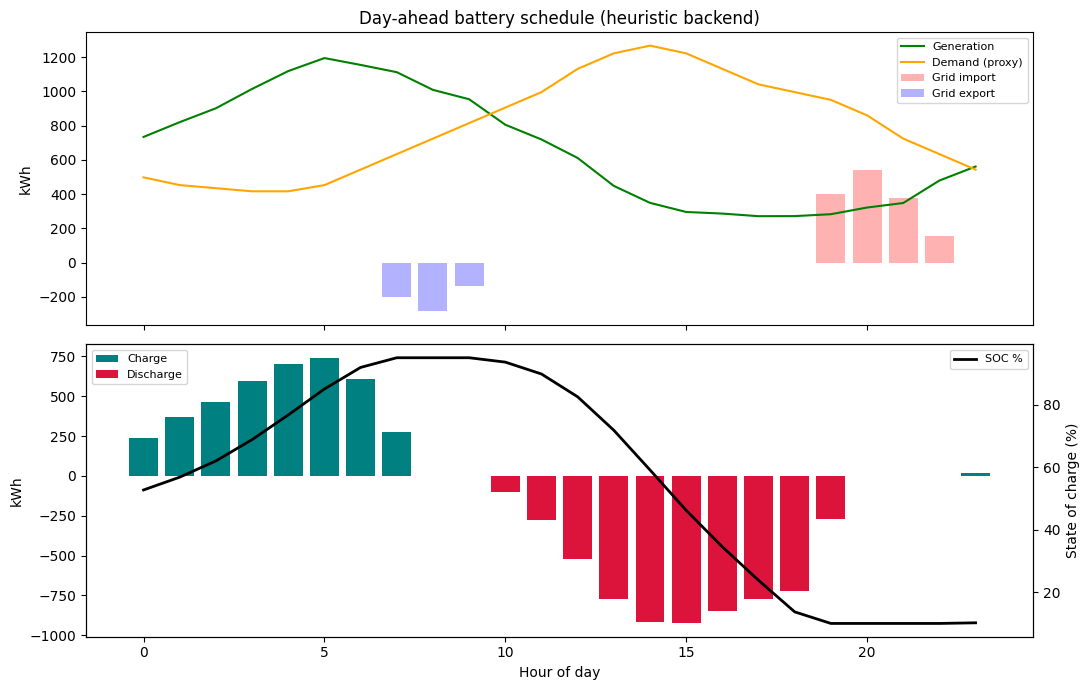

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(schedule["hour"], schedule["generation_kwh"], label="Generation", color="green")
axes[0].plot(schedule["hour"], schedule["demand_kwh"], label="Demand (proxy)", color="orange")
axes[0].bar(schedule["hour"], schedule["grid_import_kwh"], alpha=0.3, color="red", label="Grid import")
axes[0].bar(schedule["hour"], -schedule["grid_export_kwh"], alpha=0.3, color="blue", label="Grid export")
axes[0].set_ylabel("kWh")
axes[0].set_title(f"Day-ahead battery schedule ({backend} backend)")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].bar(schedule["hour"], schedule["charge_kwh"], color="teal", label="Charge")
axes[1].bar(schedule["hour"], -schedule["discharge_kwh"], color="crimson", label="Discharge")
ax2 = axes[1].twinx()
ax2.plot(schedule["hour"], schedule["soc_pct"], color="black", linewidth=2, label="SOC %")
ax2.set_ylabel("State of charge (%)")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("kWh")
axes[1].legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day7_battery_schedule.png", dpi=150)
plt.show()


## 5. Grid scenario simulations
Three scenarios per the work plan, using synthetic/dummy parameters (no real fault data exists for
this site) -- each returns a corrective action in the same `AgentResult` format as Day 6's agents,
so they log identically.

In [13]:
scenario_results = run_all_scenarios(summary, cfg)
for r in scenario_results:
    print(f"[{r.agent_name}]")
    print(f"  {r.explanation}\n")


[Grid Agent (scenario: overload)]
  OVERLOAD scenario (synthetic, +15% demand spike assumed = 3,300 kWh): Sufficient grid import headroom to absorb the spike without shedding load.

[Grid Agent (scenario: outage)]
  OUTAGE scenario (synthetic, 3h grid loss assumed, ~2,375 kWh demand to cover): Battery pool can island the site for the full 3h outage on stored charge alone.

[Grid Agent (scenario: voltage instability)]
  VOLTAGE INSTABILITY scenario (synthetic, 6.0% deviation vs. assumed +/-5.0% tolerance): Deviation outside normal tolerance but within safe range -- recommend reactive power (VAR) support to stabilize voltage before considering a trip.



## 6. Carbon/ESG metrics on the optimized schedule
More granular than Day 6's single-number estimate -- computed from the actual hourly import/export the optimizer produced.

In [14]:
carbon = compute_schedule_carbon_metrics(schedule, cfg)
for k, v in carbon.items():
    print(f"  {k}: {v}")


  total_generation_kwh: 16054.1
  total_demand_kwh: 19000.0
  renewable_covered_demand_kwh: 17531.8
  renewable_utilization_pct: 92.3
  avoided_co2_kg: 13164.4
  avoided_co2_tonnes: 13.164
  grid_import_attributed_co2_kg: 1203.9
  assumed_emission_factor_kg_per_kwh: 0.82


## 7. Log everything
Appends the three scenario results to the same log file Day 6 uses, so Day 8's dashboard can read one unified activity feed.

In [15]:
log_path = log_pipeline_run(scenario_results, cfg)
print("Logged scenarios to:", log_path)


Logged scenarios to: logs\agent_decisions_20260813.jsonl


---
## Checkpoint — Day 7 complete

- `reports/figures/day7_hourly_profiles.png` and `day7_battery_schedule.png` saved for the deck.
- Battery schedule achieved the self-sufficiency % printed in step 3 above against the
  demand proxy, using only the real generation forecast and a real historical diurnal shape.
- All three required grid scenarios simulated with synthetic parameters, clearly labeled, each
  producing a concrete corrective action.
- Carbon metrics computed on the actual optimized schedule, not just the raw forecast total.

**State plainly in the demo:** the demand-side numbers (proxy + its hourly shape) and the grid
scenario parameters are synthetic/assumed. The generation-side numbers (forecast + its hourly
shape) are grounded in real data throughout.

Next: Day 8 — Streamlit dashboard, tying forecasting, agents, optimization, and the copilot into
one visual surface.